In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

Dataset

In [2]:
train_data = pd.read_csv("../data/train.csv")

print("Training data:", train_data.shape)

Training data: (594194, 21)


In [3]:
customer_features = train_data.drop(columns=["id", "Churn"])

churn_target = train_data["Churn"].map({
    "No": 0,
    "Yes": 1
})

In [4]:
print("Input features:", customer_features.shape)
print("\nTarget counts:")
print(churn_target.value_counts())

Input features: (594194, 19)

Target counts:
Churn
0    460377
1    133817
Name: count, dtype: int64


In [5]:
numeric_features = customer_features.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = customer_features.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


Validation Split

In [6]:
X_train, X_valid, y_train, y_valid = train_test_split(
    customer_features,
    churn_target,
    test_size=0.20,
    random_state=31,
    stratify=churn_target
)

In [7]:
print("Training split:", X_train.shape)
print("Validation split:", X_valid.shape)

Training split: (475355, 19)
Validation split: (118839, 19)


Preprocessing

In [8]:
xgb_preprocessor = ColumnTransformer(
    transformers=[
        ("numbers", "passthrough", numeric_features),
        (
            "categories",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

XGBoost Model

In [9]:
xgb_model = XGBClassifier(
    n_estimators=250,
    learning_rate=0.05,
    max_depth=5,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    random_state=31,
    n_jobs=-1
)

In [10]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessing", xgb_preprocessor),
        ("classifier", xgb_model)
    ]
)

In [11]:
xgb_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numbers', 'passthrough',
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categories',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport',...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None, min_child_weight=2,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=250, n_jobs=-1,
                               num_parallel_tree=None, ...))])

Validation Predictions

In [12]:
xgb_predictions = xgb_pipeline.predict(X_valid)

xgb_probabilities = xgb_pipeline.predict_proba(
    X_valid
)[:, 1]

In [13]:
print("Class predictions:", len(xgb_predictions))
print("Probability predictions:", len(xgb_probabilities))
print("Validation rows:", len(X_valid))

Class predictions: 118839
Probability predictions: 118839
Validation rows: 118839


Model Results


In [14]:
xgb_results = {
    "Accuracy": accuracy_score(y_valid, xgb_predictions),
    "Precision": precision_score(y_valid, xgb_predictions),
    "Recall": recall_score(y_valid, xgb_predictions),
    "F1-score": f1_score(y_valid, xgb_predictions),
    "ROC-AUC": roc_auc_score(y_valid, xgb_probabilities)
}

for metric, value in xgb_results.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.8605
Precision: 0.7099
Recall: 0.6436
F1-score: 0.6751
ROC-AUC: 0.9156


In [15]:
print(
    classification_report(
        y_valid,
        xgb_predictions,
        target_names=["No Churn", "Churn"]
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.92      0.91     92076
       Churn       0.71      0.64      0.68     26763

    accuracy                           0.86    118839
   macro avg       0.80      0.78      0.79    118839
weighted avg       0.86      0.86      0.86    118839



In [16]:
xgb_confusion_matrix = confusion_matrix(
    y_valid,
    xgb_predictions
)

print(xgb_confusion_matrix)

[[85036  7040]
 [ 9539 17224]]


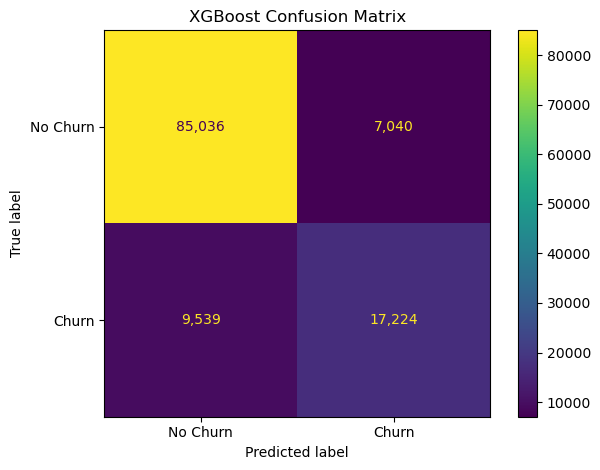

In [17]:
ConfusionMatrixDisplay.from_predictions(
    y_valid,
    xgb_predictions,
    display_labels=["No Churn", "Churn"],
    values_format=","
)

plt.title("XGBoost Confusion Matrix")
plt.tight_layout()
plt.savefig(
    "../screenshots/xgboost_confusion_matrix.png",
    dpi=150
)
plt.show()

In [18]:
model_comparison = pd.DataFrame(
    [
        {
            "Accuracy": 0.8546,
            "Precision": 0.6845,
            "Recall": 0.6576,
            "F1-score": 0.6708,
            "ROC-AUC": 0.9082
        },
        {
            "Accuracy": 0.8075,
            "Precision": 0.5447,
            "Recall": 0.8835,
            "F1-score": 0.6739,
            "ROC-AUC": 0.9081
        },
        {
            "Accuracy": 0.8577,
            "Precision": 0.7002,
            "Recall": 0.6435,
            "F1-score": 0.6707,
            "ROC-AUC": 0.9123
        },
        xgb_results
    ],
    index=[
        "Logistic Regression",
        "Weighted Logistic Regression",
        "Random Forest",
        "XGBoost"
    ]
)

model_comparison.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.8546,0.6845,0.6576,0.6708,0.9082
Weighted Logistic Regression,0.8075,0.5447,0.8835,0.6739,0.9081
Random Forest,0.8577,0.7002,0.6435,0.6707,0.9123
XGBoost,0.8605,0.7099,0.6436,0.6751,0.9156


Generate validation probabilities

In [19]:
print("Probability values:", len(xgb_probabilities))
print("Validation labels:", len(y_valid))

print("\nFirst five churn probabilities:")
print(xgb_probabilities[:5])

Probability values: 118839
Validation labels: 118839

First five churn probabilities:
[0.05145205 0.19451031 0.8523066  0.38363573 0.09550519]


In [20]:
original_xgb_predictions = (
    xgb_probabilities >= 0.50
).astype(int)

In [21]:
original_threshold_results = {
    "Accuracy": accuracy_score(y_valid, original_xgb_predictions),
    "Precision": precision_score(y_valid, original_xgb_predictions),
    "Recall": recall_score(y_valid, original_xgb_predictions),
    "F1-score": f1_score(y_valid, original_xgb_predictions),
    "ROC-AUC": roc_auc_score(y_valid, xgb_probabilities)
}

for metric, value in original_threshold_results.items():
    print(f"{metric}: {value:.4f}")

Accuracy: 0.8605
Precision: 0.7099
Recall: 0.6436
F1-score: 0.6751
ROC-AUC: 0.9156


In [22]:
thresholds_to_test = [
    0.30,
    0.35,
    0.40,
    0.45,
    0.50,
    0.55,
    0.60
]

threshold_results = []

for threshold in thresholds_to_test:
    predictions_at_threshold = (
        xgb_probabilities >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(
            y_valid,
            predictions_at_threshold
        ),
        "Precision": precision_score(
            y_valid,
            predictions_at_threshold
        ),
        "Recall": recall_score(
            y_valid,
            predictions_at_threshold
        ),
        "F1-score": f1_score(
            y_valid,
            predictions_at_threshold
        )
    })

threshold_table = pd.DataFrame(threshold_results)

threshold_table.round(4)

,Threshold,Accuracy,Precision,Recall,F1-score
0,0.30,0.8376,0.6008,0.8303,0.6972
1,0.35,0.8479,0.6285,0.7940,0.7016
2,0.40,0.8542,0.6528,0.7528,0.6992
3,0.45,0.8586,0.6796,0.7043,0.6917
4,0.50,0.8605,0.7099,0.6436,0.6751
5,0.55,0.8604,0.7384,0.5885,0.6550
6,0.60,0.8563,0.7689,0.5175,0.6186


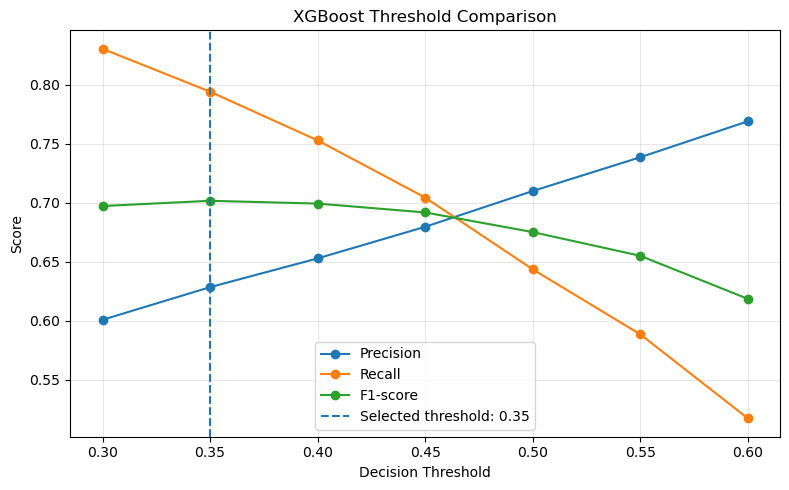

In [23]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_table["Threshold"],
    threshold_table["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_table["Threshold"],
    threshold_table["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_table["Threshold"],
    threshold_table["F1-score"],
    marker="o",
    label="F1-score"
)

plt.axvline(
    0.35,
    linestyle="--",
    label="Selected threshold: 0.35"
)

plt.title("XGBoost Threshold Comparison")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "../screenshots/xgboost_threshold_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [24]:
best_f1_result = threshold_table.loc[
    threshold_table["F1-score"].idxmax()
]

print("Threshold with the highest F1-score:")
print(best_f1_result.round(4))

Threshold with the highest F1-score:
Threshold    0.3500
Accuracy     0.8479
Precision    0.6285
Recall       0.7940
F1-score     0.7016
Name: 1, dtype: float64


In [25]:
threshold_table.to_csv(
    "../report/xgboost_threshold_comparison.csv",
    index=False
)

In [26]:
selected_threshold = 0.35

selected_predictions = (
    xgb_probabilities >= selected_threshold
).astype(int)

selected_confusion_matrix = confusion_matrix(
    y_valid,
    selected_predictions
)

print("Confusion matrix at threshold 0.35:")
print(selected_confusion_matrix)

print("\nClassification report:")
print(
    classification_report(
        y_valid,
        selected_predictions,
        target_names=["No Churn", "Churn"]
    )
)

Confusion matrix at threshold 0.35:
[[79515 12561]
 [ 5514 21249]]

Classification report:
              precision    recall  f1-score   support

    No Churn       0.94      0.86      0.90     92076
       Churn       0.63      0.79      0.70     26763

    accuracy                           0.85    118839
   macro avg       0.78      0.83      0.80    118839
weighted avg       0.87      0.85      0.85    118839



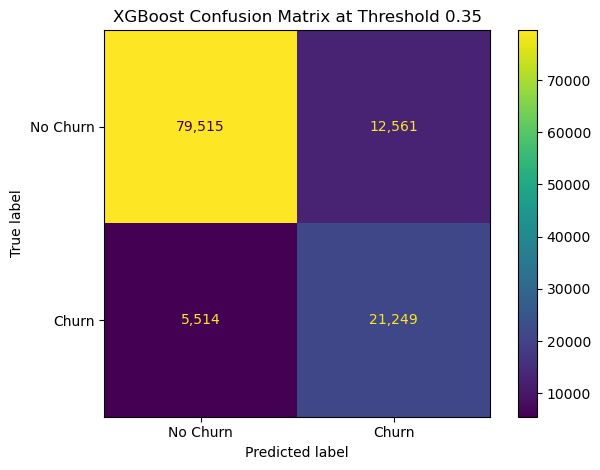

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_valid,
    selected_predictions,
    display_labels=["No Churn", "Churn"],
    values_format=","
)

plt.title("XGBoost Confusion Matrix at Threshold 0.35")
plt.tight_layout()
plt.savefig(
    "../screenshots/xgboost_threshold_035_confusion_matrix.png",
    dpi=150
)
plt.show()

In [28]:
test_data = pd.read_csv("../data/test.csv")
sample_submission = pd.read_csv("../data/sample_submission.csv")

print("Test data:", test_data.shape)
print("Submission template:", sample_submission.shape)

sample_submission.head()

Test data: (254655, 20)
Submission template: (254655, 2)


,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,0


In [29]:
full_training_features = train_data.drop(columns=["id", "Churn"])
full_training_target = train_data["Churn"].map({
    "No": 0,
    "Yes": 1
})

kaggle_test_features = test_data.drop(columns=["id"])

In [30]:
xgb_pipeline.fit(
    full_training_features,
    full_training_target
)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('numbers', 'passthrough',
                                                  ['SeniorCitizen', 'tenure',
                                                   'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('categories',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'Partner',
                                                   'Dependents', 'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport',...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None, min_child_weight=2,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=250, n_jobs=-1,
                               num_parallel_tree=None, ...))])

In [31]:
test_churn_probabilities = xgb_pipeline.predict_proba(
    kaggle_test_features
)[:, 1]

print("Number of test predictions:", len(test_churn_probabilities))
print("Lowest probability:", test_churn_probabilities.min())
print("Highest probability:", test_churn_probabilities.max())

Number of test predictions: 254655
Lowest probability: 0.0006245855
Highest probability: 0.9831346


In [32]:
submission_xgb = sample_submission.copy()

submission_xgb["id"] = test_data["id"]
submission_xgb["Churn"] = test_churn_probabilities

submission_xgb.head()

,id,Churn
0,594194,0.056065
1,594195,0.001217
2,594196,0.105608
3,594197,0.002752
4,594198,0.525201


In [33]:
print("Submission shape:", submission_xgb.shape)
print("\nMissing values:")
print(submission_xgb.isnull().sum())

print("\nColumn names:")
print(submission_xgb.columns.tolist())

Submission shape: (254655, 2)

Missing values:
id       0
Churn    0
dtype: int64

Column names:
['id', 'Churn']


In [34]:
submission_xgb.to_csv(
    "../report/submission_xgboost_v1.csv",
    index=False
)

In [35]:
binary_submission_xgb = sample_submission.copy()

binary_submission_xgb["id"] = test_data["id"]

binary_submission_xgb["Churn"] = (
    test_churn_probabilities >= selected_threshold
).astype(int)

binary_submission_xgb.head()

,id,Churn
0,594194,0
1,594195,0
2,594196,0
3,594197,0
4,594198,1


In [36]:
binary_submission_xgb.to_csv(
    "../report/submission_xgboost_threshold_035.csv",
    index=False
)

In [37]:
xgb_options = {
    "Current XGBoost": XGBClassifier(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=5,
        min_child_weight=2,
        subsample=0.85,
        colsample_bytree=0.85,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=31,
        n_jobs=-1
    ),

    "XGBoost Option 2": XGBClassifier(
        n_estimators=350,
        learning_rate=0.03,
        max_depth=5,
        min_child_weight=3,
        subsample=0.90,
        colsample_bytree=0.90,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=31,
        n_jobs=-1
    ),

    "XGBoost Option 3": XGBClassifier(
        n_estimators=300,
        learning_rate=0.04,
        max_depth=6,
        min_child_weight=3,
        subsample=0.85,
        colsample_bytree=0.90,
        reg_lambda=1.5,
        objective="binary:logistic",
        eval_metric="auc",
        tree_method="hist",
        random_state=31,
        n_jobs=-1
    )
}

In [38]:
from sklearn.base import clone

xgb_tuning_results = []
trained_xgb_pipelines = {}

for option_name, option_model in xgb_options.items():

    option_pipeline = Pipeline(
        steps=[
            ("preprocessing", clone(xgb_preprocessor)),
            ("classifier", option_model)
        ]
    )

    print(f"Training: {option_name}")

    option_pipeline.fit(X_train, y_train)

    option_probabilities = option_pipeline.predict_proba(X_valid)[:, 1]
    option_predictions = (option_probabilities >= 0.50).astype(int)

    option_results = {
        "Model": option_name,
        "Accuracy": accuracy_score(y_valid, option_predictions),
        "Precision": precision_score(y_valid, option_predictions),
        "Recall": recall_score(y_valid, option_predictions),
        "F1-score": f1_score(y_valid, option_predictions),
        "ROC-AUC": roc_auc_score(y_valid, option_probabilities)
    }

    xgb_tuning_results.append(option_results)
    trained_xgb_pipelines[option_name] = option_pipeline

    print(
        f"ROC-AUC: {option_results['ROC-AUC']:.4f} | "
        f"F1-score: {option_results['F1-score']:.4f}\n"
    )

Training: Current XGBoost
ROC-AUC: 0.9156 | F1-score: 0.6751

Training: XGBoost Option 2
ROC-AUC: 0.9152 | F1-score: 0.6739

Training: XGBoost Option 3
ROC-AUC: 0.9159 | F1-score: 0.6762



In [39]:
xgb_tuning_table = pd.DataFrame(xgb_tuning_results)

xgb_tuning_table = xgb_tuning_table.set_index("Model")

xgb_tuning_table.round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
Current XGBoost,0.8605,0.7099,0.6436,0.6751,0.9156
XGBoost Option 2,0.8600,0.7089,0.6423,0.6739,0.9152
XGBoost Option 3,0.8608,0.7102,0.6453,0.6762,0.9159


In [40]:
xgb_tuning_table.sort_values(
    "ROC-AUC",
    ascending=False
).round(4)

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Model,,,,,
XGBoost Option 3,0.8608,0.7102,0.6453,0.6762,0.9159
Current XGBoost,0.8605,0.7099,0.6436,0.6751,0.9156
XGBoost Option 2,0.8600,0.7089,0.6423,0.6739,0.9152


In [41]:
best_xgb_name = xgb_tuning_table["ROC-AUC"].idxmax()
best_xgb_score = xgb_tuning_table.loc[best_xgb_name, "ROC-AUC"]

print("Best XGBoost option:", best_xgb_name)
print("Best validation ROC-AUC:", round(best_xgb_score, 4))

Best XGBoost option: XGBoost Option 3
Best validation ROC-AUC: 0.9159


In [42]:
best_xgb_pipeline = trained_xgb_pipelines[best_xgb_name]

In [43]:
xgb_tuning_table.to_csv(
    "../report/xgboost_tuning_comparison.csv",
    index=True
)

In [44]:
if "xgb_pipeline" in globals():
    try:
        xgb_pipeline.named_steps["classifier"].get_booster()
        print("XGBoost pipeline is trained.")
    except Exception:
        print("Pipeline exists, but it is not trained.")

XGBoost pipeline is trained.


In [45]:
import os
import joblib

model_directory = "../app/model"
os.makedirs(model_directory, exist_ok=True)

model_path = os.path.join(
    model_directory,
    "final_xgboost_pipeline.joblib"
)

joblib.dump(
    xgb_pipeline,
    model_path
)


['../app/model\\final_xgboost_pipeline.joblib']

In [46]:
import json

model_information = {
    "model_name": "XGBoost",
    "decision_threshold": 0.35,
    "validation_roc_auc": 0.9156,
    "validation_accuracy_at_050": 0.8605,
    "validation_precision_at_035": 0.6285,
    "validation_recall_at_035": 0.7940,
    "validation_f1_at_035": 0.7016,
    "kaggle_public_score": 0.91240,
    "kaggle_private_score": 0.91372,
    "input_feature_count": 19,
    "random_state": 31
}

information_path = "../app/model/model_information.json"

with open(information_path, "w") as information_file:
    json.dump(model_information, information_file, indent=4)

print("Model information saved to:", information_path)

Model information saved to: ../app/model/model_information.json


In [47]:
loaded_pipeline = joblib.load(
    "../app/model/final_xgboost_pipeline.joblib"
)


In [48]:
train_data = pd.read_csv("../data/train.csv")

sample_customer = train_data.drop(
    columns=["id", "Churn"]
).iloc[[0]]

sample_customer

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,No,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85


In [49]:
sample_probability = loaded_pipeline.predict_proba(
    sample_customer
)[:, 1][0]

print(
    "Sample churn probability:",
    round(sample_probability, 4)
)

Sample churn probability: 0.01


In [50]:
decision_threshold = 0.35

if sample_probability >= decision_threshold:
    sample_result = "Churn risk"
else:
    sample_result = "No churn risk"

print("Sample result:", sample_result)

Sample result: No churn risk


In [51]:
import os

model_size_bytes = os.path.getsize(
    "../app/model/final_xgboost_pipeline.joblib"
)

model_size_mb = model_size_bytes / (1024 * 1024)

print("Saved model size:", round(model_size_mb, 2), "MB")

Saved model size: 0.68 MB
